In [1]:
import sys, time
print("HELLO NOTEBOOK", flush=True)
print("python =", sys.executable, flush=True)
time.sleep(1)
print("AFTER 1s", flush=True)


HELLO NOTEBOOK
python = /opt/homebrew/opt/python@3.11/bin/python3.11
AFTER 1s


In [2]:
import sys
!{sys.executable} -m pip install -U duckdb


In [3]:
import duckdb
print("duckdb version:", duckdb.__version__)


duckdb version: 1.4.3


In [4]:
import os
import numpy as np
import pandas as pd

# ====== 输入文件 ======
CSV1 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class_shp_filtered.csv"
CSV2 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class_shp_filtered.csv"

COST_XLSX = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/成本计算/13_park_medical_and_landprice_with_geo_type_maintenance_2024.xlsx"
BASE_SHP  = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/3_urbanpark_research_area/urbanpark_research_area.shp"

# ====== 输出文件夹 ======
OUT_DIR = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
os.makedirs(OUT_DIR, exist_ok=True)

DUCKDB_PATH   = os.path.join(OUT_DIR, "tmp_payback.duckdb")
PARK_PARQUET  = os.path.join(OUT_DIR, "park_agg.parquet")
USERS_TXT     = os.path.join(OUT_DIR, "approx_unique_users.txt")
OUT_TABLE_CSV = os.path.join(OUT_DIR, "park_payback_table.csv")
OUT_FIG_PNG   = os.path.join(OUT_DIR, "park_payback_map.png")

# ====== 经济参数 ======
YEN_PER_STEP = 0.04
COEF_NUMERATOR = 320000
PAYBACK_HORIZON = 50.0

# ====== 点大小映射参数（可调） ======
SIZE_MIN = 6
SIZE_MAX = 180
SIZE_Q   = 0.99  # 用 sqrt(area) 的 99% 分位做缩放，避免极大公园压扁其他点

# ====== 简单检查 ======
for p in [CSV1, CSV2, COST_XLSX, BASE_SHP]:
    if not os.path.exists(p):
        raise FileNotFoundError(p)

print("OK: all input paths exist")
print("OUT_DIR =", OUT_DIR)


OK: all input paths exist
OUT_DIR = /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output


In [5]:
import sys
!{sys.executable} -m pip install -U pyarrow


In [6]:
import time
import duckdb
import os

# 新增：公园聚合输出 CSV（不用 parquet/pyarrow）
PARK_AGG_CSV = os.path.join(OUT_DIR, "park_agg.csv")

t0 = time.perf_counter()
print("DuckDB: start aggregation (CSV + EXACT users)...", flush=True)

con = duckdb.connect(DUCKDB_PATH)

# 多线程（notebook 不开 progress bar，避免 ipywidgets 报错）
con.execute("PRAGMA threads=8;")
con.execute("PRAGMA preserve_insertion_order=false;")

# 统一视图：两份CSV union all
con.execute(f"""
    CREATE OR REPLACE VIEW v AS
    SELECT
        CAST(user_ID AS VARCHAR) AS user_ID,
        CAST(osm_id  AS VARCHAR) AS osm_id,
        CAST(Lat     AS DOUBLE)  AS Lat,
        CAST(Lng     AS DOUBLE)  AS Lng,
        CAST(area    AS DOUBLE)  AS area,
        CAST(steps   AS DOUBLE)  AS steps,
        CAST(park_class_name AS VARCHAR) AS park_class_name
    FROM read_csv_auto('{CSV1}', ignore_errors=true)
    UNION ALL
    SELECT
        CAST(user_ID AS VARCHAR) AS user_ID,
        CAST(osm_id  AS VARCHAR) AS osm_id,
        CAST(Lat     AS DOUBLE)  AS Lat,
        CAST(Lng     AS DOUBLE)  AS Lng,
        CAST(area    AS DOUBLE)  AS area,
        CAST(steps   AS DOUBLE)  AS steps,
        CAST(park_class_name AS VARCHAR) AS park_class_name
    FROM read_csv_auto('{CSV2}', ignore_errors=true);
""")
print("DuckDB: view created", flush=True)

# ——关键修改：精确 distinct user 数（不近似）
# 同时排除空字符串，避免把 "" 当成一个用户
print("DuckDB: counting DISTINCT user_ID (EXACT)...", flush=True)
n_users_exact = con.execute("""
    SELECT COUNT(DISTINCT user_ID) AS n_users
    FROM v
    WHERE user_ID IS NOT NULL AND length(trim(user_ID)) > 0;
""").fetchone()[0]
n_users_exact = int(n_users_exact)
print(f"EXACT unique users = {n_users_exact:,}", flush=True)

with open(USERS_TXT, "w", encoding="utf-8") as f:
    f.write(str(n_users_exact))

# 公园聚合输出 CSV（避免 parquet 依赖）
print("DuckDB: aggregating parks -> CSV ...", flush=True)
con.execute(f"""
    COPY (
        SELECT
            osm_id,
            avg(Lat) AS Lat,
            avg(Lng) AS Lng,
            any_value(area) AS area_m2,
            any_value(park_class_name) AS park_class_name,
            sum(coalesce(steps, 0.0)) AS steps_sum,
            count(*) AS n_visits
        FROM v
        WHERE osm_id IS NOT NULL
          AND Lat IS NOT NULL AND Lng IS NOT NULL
        GROUP BY osm_id
    ) TO '{PARK_AGG_CSV}' (HEADER, DELIMITER ',');
""")

con.close()

print("Wrote users:", USERS_TXT, flush=True)
print("Wrote parks:", PARK_AGG_CSV, flush=True)
print(f"DuckDB done in {time.perf_counter()-t0:.1f}s", flush=True)


DuckDB: start aggregation (CSV + EXACT users)...
DuckDB: view created
DuckDB: counting DISTINCT user_ID (EXACT)...
EXACT unique users = 821,992
DuckDB: aggregating parks -> CSV ...
Wrote users: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/approx_unique_users.txt
Wrote parks: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_agg.csv
DuckDB done in 1.0s


In [7]:
import sys
!{sys.executable} -m pip install -U openpyxl


In [8]:
import os, time
import numpy as np
import pandas as pd

t0 = time.perf_counter()

PARK_AGG_CSV = os.path.join(OUT_DIR, "park_agg.csv")
coef = 134.38

def norm_osm(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)  # 把 123.0 -> 123
    return s

# --- parks
parks = pd.read_csv(PARK_AGG_CSV)
parks["osm_id_norm"] = norm_osm(parks["osm_id"])

# --- cost
cost = pd.read_excel(
    COST_XLSX,
    usecols=["osm_id", "price_fina", "unit_maintenance_yen_per_m2_2024"],
    engine="openpyxl",
)
cost["osm_id_norm"] = norm_osm(cost["osm_id"])
cost["price_fina"] = pd.to_numeric(cost["price_fina"], errors="coerce")
cost["unit_maintenance_yen_per_m2_2024"] = pd.to_numeric(cost["unit_maintenance_yen_per_m2_2024"], errors="coerce")
cost = cost.drop_duplicates("osm_id_norm", keep="last")

# --- merge (关键：用 osm_id_norm)
df = parks.merge(
    cost[["osm_id_norm", "price_fina", "unit_maintenance_yen_per_m2_2024"]],
    on="osm_id_norm",
    how="left",
)

# --- 成本
df["area_m2"] = pd.to_numeric(df["area_m2"], errors="coerce")
df["land_cost_yen"] = df["price_fina"] * df["area_m2"]
df["annual_maint_yen"] = df["unit_maintenance_yen_per_m2_2024"] * df["area_m2"]

# --- 收益（重新算，避免你之前 coef back-check 还停留在 131）
df["steps_sum"] = pd.to_numeric(df["steps_sum"], errors="coerce").fillna(0.0)
df["annual_benefit_yen"] = df["steps_sum"] * YEN_PER_STEP * coef

# --- 净收益 & 回本
df["net_annual_yen"] = df["annual_benefit_yen"] - df["annual_maint_yen"]

df["payback_years"] = np.where(
    (df["net_annual_yen"] > 0) & np.isfinite(df["net_annual_yen"]) & np.isfinite(df["land_cost_yen"]),
    df["land_cost_yen"] / df["net_annual_yen"],
    np.nan,
)

df["is_black"] = df["payback_years"].isna() | (df["payback_years"] > PAYBACK_HORIZON)
df["payback_clip"] = df["payback_years"].clip(lower=0, upper=PAYBACK_HORIZON)

# --- 诊断：匹配率/NaN/<=50
match_rate_price = 1 - df["price_fina"].isna().mean()
match_rate_maint  = 1 - df["unit_maintenance_yen_per_m2_2024"].isna().mean()

# coef back-check（应该接近 134.38）
m = (df["steps_sum"] > 0) & df["annual_benefit_yen"].notna()
coef_back = (df.loc[m, "annual_benefit_yen"] / (df.loc[m, "steps_sum"] * YEN_PER_STEP)).median()

print("parks rows:", f"{len(df):,}")
print("match rate price_fina:", f"{match_rate_price:.2%}")
print("match rate maintenance:", f"{match_rate_maint:.2%}")
print("coef back-check (median):", float(coef_back))
print("payback NaN share:", f"{df['payback_years'].isna().mean():.2%}")
print("<=50 share:", f"{(df['payback_years']<=50).mean():.2%}")
print("black share:", f"{df['is_black'].mean():.2%}")

df.to_csv(OUT_TABLE_CSV, index=False, encoding="utf-8-sig")
print("Saved:", OUT_TABLE_CSV)
print(f"Cell3 done in {time.perf_counter()-t0:.1f}s")

df.head()


parks rows: 4,820
match rate price_fina: 99.98%
match rate maintenance: 99.98%
coef back-check (median): 134.38
payback NaN share: 1.29%
<=50 share: 39.07%
black share: 60.93%
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_table.csv
Cell3 done in 0.7s


,osm_id,Lat,Lng,area_m2,park_class_name,steps_sum,n_visits,osm_id_norm,price_fina,unit_maintenance_yen_per_m2_2024,land_cost_yen,annual_maint_yen,annual_benefit_yen,net_annual_yen,payback_years,is_black,payback_clip
0,60973069.0,35.586664,139.649525,365886.0,Comprehensive Park,616126925.0,12630,60973069,491000.0,67.0,1.796500e+11,24514362.0,3.311805e+09,3.287291e+09,54.649869,True,50.000000
1,32305435.0,35.765561,139.630001,607824.0,Regional Park,432437275.0,14080,32305435,441750.0,315.0,2.685063e+11,191464560.0,2.324437e+09,2.132972e+09,125.883611,True,50.000000
2,597773244.0,35.673749,139.777004,5114.0,Neighborhood Park,60422225.0,957,597773244,3538750.0,225.0,1.809717e+10,1150650.0,3.247815e+08,3.236309e+08,55.919159,True,50.000000
3,162972760.0,35.437270,139.451495,75000.0,District Park,70980486.0,3572,162972760,133500.0,270.0,1.001250e+10,20250000.0,3.815343e+08,3.612843e+08,27.713631,False,27.713631
4,35610457.0,35.912269,139.450297,396000.0,Comprehensive Park,84713406.0,3261,35610457,119000.0,315.0,4.712400e+10,124740000.0,4.553515e+08,3.306115e+08,142.535877,True,50.000000


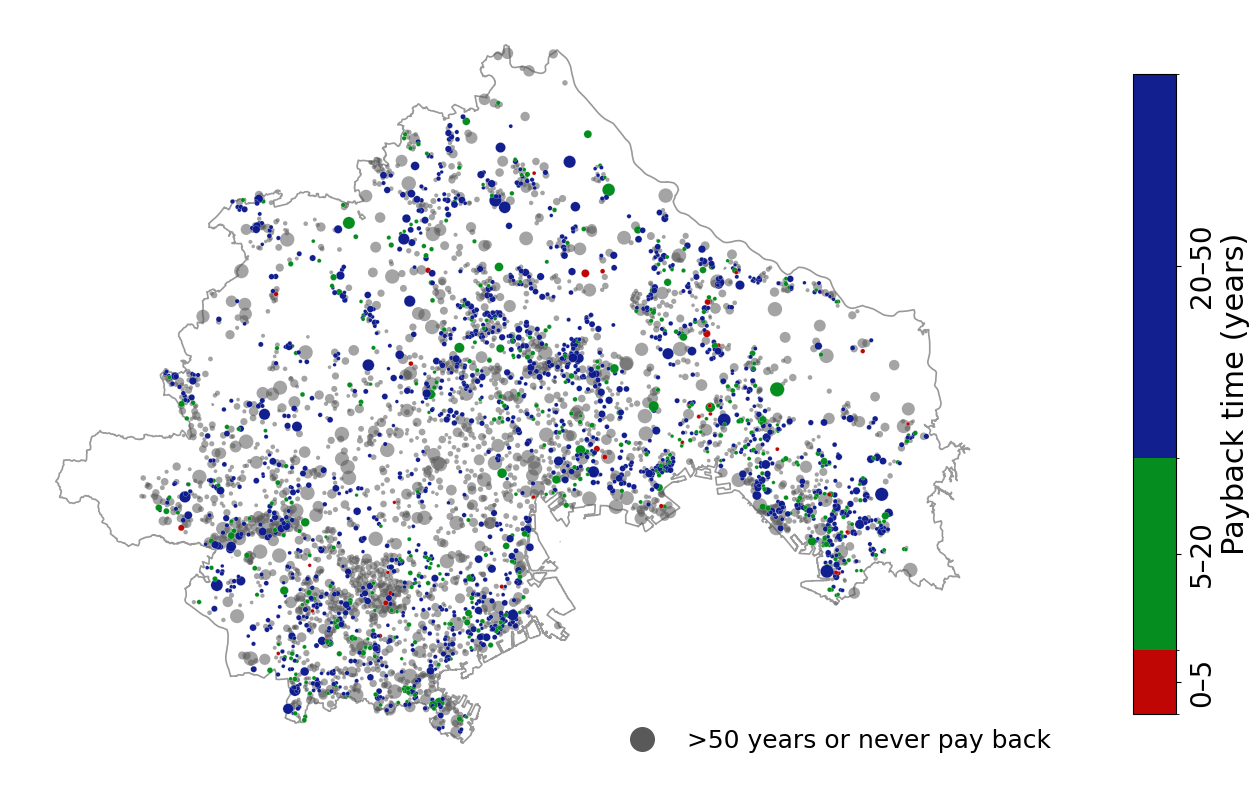

In [44]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm

# =========================
# ✅ A) 你主要要调的参数（主体更大 + 图例右移 + tick旋转）
# =========================
TEXT_SCALE = 2.0

FIGSIZE = (14.5, 8.0)          # ✅ 放大画布（主体更大）
CBAR_WIDTH = 0.03             # ✅ colorbar 轴宽度（越小主体越大）
CBAR_PAD = 0.005               # ✅ 主图与 colorbar 间距（越小主体越大）
CBAR_RIGHT = 0.9             # ✅ colorbar 靠右程度（越接近1越右）

CBAR_TICK_ROT = 90             # ✅ 0–5/5–20/20–50 逆时针 90°（rotation=90）
CBAR_TICK_PAD = 15              # tick 与色条的距离（避免挤）

# ✅ 灰点 legend（">50 years..."）向右平移
LEG_LOC = "lower center"
LEG_BBOX = (0.82, 0.02)        # ✅ (x越大越往右, y越大越往上)
LEG_MARKERSIZE = 8.5 * TEXT_SCALE

plt.rcParams.update({
    "font.size":        11 * TEXT_SCALE,
    "axes.labelsize":   11 * TEXT_SCALE,
    "xtick.labelsize":  10 * TEXT_SCALE,
    "ytick.labelsize":  10 * TEXT_SCALE,
    "legend.fontsize":   9 * TEXT_SCALE,
})

# =========================
# 0) INPUTS / DEFAULTS
# =========================
BASE_SHP = globals().get(
    "BASE_SHP",
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/3_urbanpark_research_area/urbanpark_research_area.shp"
)
PARKS_CSV = globals().get(
    "PARKS_CSV",
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_table.csv"
)

PAYBACK_HORIZON = float(globals().get("PAYBACK_HORIZON", 50))
SIZE_Q   = float(globals().get("SIZE_Q", 0.90))
SIZE_MIN = float(globals().get("SIZE_MIN", 4))
SIZE_MAX = float(globals().get("SIZE_MAX", 220))

SAVE_FIG = bool(globals().get("SAVE_FIG", False))
OUT_FIG_PNG = globals().get("OUT_FIG_PNG", "park_payback_distribution_discrete_no_inset.png")

# =========================
# 1) Prepare df
# =========================
if "df" not in globals():
    df = pd.read_csv(PARKS_CSV, encoding="utf-8-sig")

if "Lng" not in df.columns or "Lat" not in df.columns:
    lon_candidates = [c for c in ["Lng","lon","longitude","Lon","LONG"] if c in df.columns]
    lat_candidates = [c for c in ["Lat","lat","latitude","LAT"] if c in df.columns]
    if lon_candidates and lat_candidates:
        df = df.rename(columns={lon_candidates[0]:"Lng", lat_candidates[0]:"Lat"})
    else:
        raise KeyError("Cannot find longitude/latitude columns (Lng/Lat or lon/lat) in df.")

if "area_m2" not in df.columns:
    area_candidates = [c for c in ["area","Area_m2","area_m2","Area m2","Area m2 "] if c in df.columns]
    if area_candidates:
        df = df.rename(columns={area_candidates[0]:"area_m2"})
    else:
        raise KeyError("Cannot find area column (area_m2 / area / Area_m2...) in df.")

if "payback_years" not in df.columns:
    raise KeyError("df must contain payback_years (observed payback).")

for c in ["Lng","Lat","area_m2","payback_years"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["is_black"] = (~np.isfinite(df["payback_years"])) | (df["payback_years"] > PAYBACK_HORIZON)
df["payback_color_val"] = df["payback_years"].copy()
df.loc[df["is_black"], "payback_color_val"] = np.nan
df = df[np.isfinite(df["Lng"]) & np.isfinite(df["Lat"])].copy()

# =========================
# 2) Discrete 3-color mapping
# =========================
COLOR_RED   = (0.75, 0.00, 0.00)
COLOR_GREEN = (0.00, 0.55, 0.10)
COLOR_BLUE  = (0.05, 0.10, 0.55)
CMAP = ListedColormap([COLOR_RED, COLOR_GREEN, COLOR_BLUE], name="payback_discrete_rgb")

BOUNDS = np.array([0.0, 5.0, 20.0, PAYBACK_HORIZON], dtype=float)
NORM = BoundaryNorm(BOUNDS, CMAP.N, clip=True)

# =========================
# 3) Base outline + points
# =========================
base = gpd.read_file(BASE_SHP)
base_outline = base.dissolve()

gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["Lng"], df["Lat"]),
    crs="EPSG:4326",
)
if base_outline.crs is not None and str(base_outline.crs) != str(gdf.crs):
    gdf = gdf.to_crs(base_outline.crs)

# =========================
# 4) Point sizes
# =========================
area = pd.to_numeric(gdf["area_m2"], errors="coerce").fillna(0).clip(lower=0)
sqrt_area = np.sqrt(area)

denom = np.nanquantile(sqrt_area.replace(0, np.nan), SIZE_Q)
if not np.isfinite(denom) or denom <= 0:
    denom = np.nanmax(sqrt_area) if np.nanmax(sqrt_area) > 0 else 1.0

sizes = (sqrt_area / denom) * SIZE_MAX
sizes = sizes.clip(lower=SIZE_MIN, upper=SIZE_MAX)
sizes = sizes * 0.6
gdf["pt_size"] = sizes

g_col = gdf[~gdf["is_black"]].copy()
g_blk = gdf[gdf["is_black"]].copy()

# =========================
# 5) Plot（关键：用手动布局，把主体做大）
# =========================
fig = plt.figure(figsize=FIGSIZE)

# ✅ 主体地图轴：尽量占满左侧
ax = fig.add_axes([0.02, 0.02, CBAR_RIGHT - CBAR_WIDTH - CBAR_PAD - 0.02, 0.96])

# ✅ colorbar 轴：贴右侧，且更窄
cax = fig.add_axes([CBAR_RIGHT - CBAR_WIDTH, 0.10, CBAR_WIDTH, 0.80])

# base outline
base_outline.boundary.plot(ax=ax, linewidth=1.2, color="0.6", zorder=1)

# gray points: >50 or NaN
ax.scatter(
    g_blk.geometry.x, g_blk.geometry.y,
    s=g_blk["pt_size"].values,
    color="0.35",
    alpha=0.55,
    linewidths=0,
    zorder=2
)

# colored points (<=50)
sc = ax.scatter(
    g_col.geometry.x, g_col.geometry.y,
    s=g_col["pt_size"].values,
    c=g_col["payback_color_val"].values,
    cmap=CMAP,
    norm=NORM,
    alpha=0.98,
    linewidths=0.15,
    edgecolors="white",
    zorder=3
)

# =========================
# ✅ colorbar：tick 标签旋转 90°，避免互相挤
# =========================
cbar = fig.colorbar(
    sc, cax=cax,
    boundaries=BOUNDS, spacing="proportional"
)
cbar.set_label("Payback time (years)", fontsize=11 * TEXT_SCALE)
cbar.set_ticks([2.5, 12.5, 35.0])
cbar.set_ticklabels(["0–5", "5–20", "20–50"])
cbar.ax.tick_params(labelsize=10 * TEXT_SCALE, pad=CBAR_TICK_PAD)

# ✅ 关键：把 0–5 / 5–20 / 20–50 逆时针旋转 90°
for t in cbar.ax.get_yticklabels():
    t.set_rotation(CBAR_TICK_ROT)   # 90 = 逆时针90度
    t.set_va("center")
    t.set_ha("center")

# =========================
# ✅ 灰点 legend：向右平移，别压点
# =========================
leg = ax.legend(
    handles=[
        Line2D([0], [0], marker="o", color="w",
               label=">50 years or never pay back",
               markerfacecolor="0.35", markeredgecolor="0.35",
               markersize=LEG_MARKERSIZE)
    ],
    loc=LEG_LOC,
    bbox_to_anchor=LEG_BBOX,
    frameon=True,
    framealpha=0.88,
    borderaxespad=0.0
)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_edgecolor("none")

ax.set_axis_off()

if SAVE_FIG:
    fig.savefig(OUT_FIG_PNG, dpi=220, bbox_inches="tight")
    print("Saved:", OUT_FIG_PNG)

plt.show()


/var/folders/98/dxfywpxj3x5b43cvqj3dbh6m0000gn/T/ipykernel_47700/1639097381.py:261: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


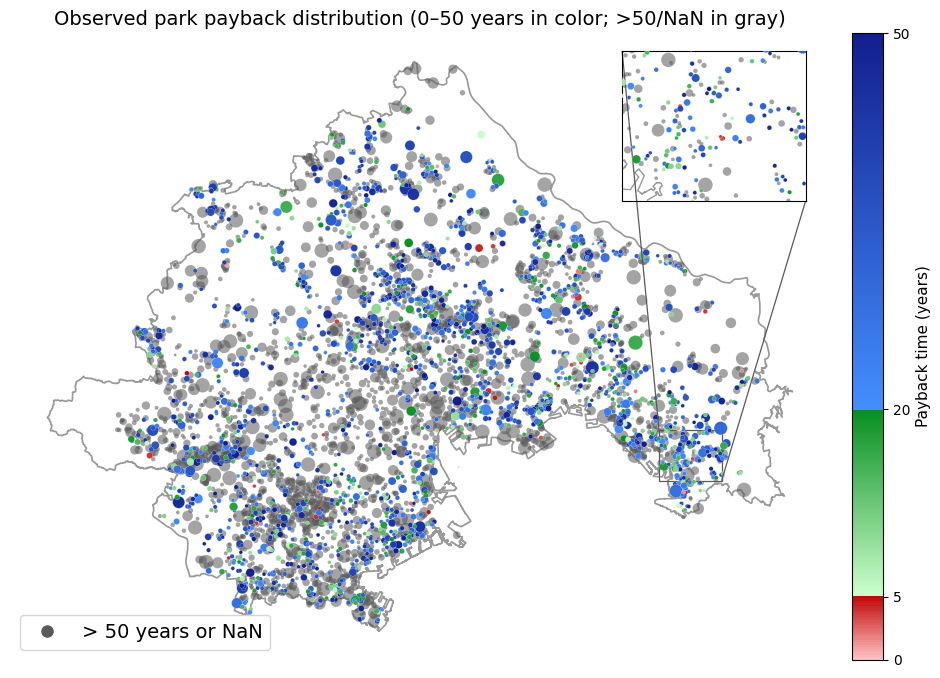

[Inset extent in map CRS] xmin,xmax,ymin,ymax = (np.float64(140.09727870153904), np.float64(140.19299594476456), np.float64(35.5890809595506), np.float64(35.65269516673008))


In [32]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize, LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# =========================
# 0) INPUTS / DEFAULTS
# =========================
BASE_SHP = globals().get(
    "BASE_SHP",
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/3_urbanpark_research_area/urbanpark_research_area.shp"
)
PARKS_CSV = globals().get(
    "PARKS_CSV",
    r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_table.csv"
)

PAYBACK_HORIZON = float(globals().get("PAYBACK_HORIZON", 50))
SIZE_Q   = float(globals().get("SIZE_Q", 0.90))
SIZE_MIN = float(globals().get("SIZE_MIN", 4))
SIZE_MAX = float(globals().get("SIZE_MAX", 220))

SAVE_FIG = bool(globals().get("SAVE_FIG", False))
OUT_FIG_PNG = globals().get("OUT_FIG_PNG", "park_payback_distribution_piecewise_inset.png")

# ===== inset 控制 =====
AUTO_INSET = True
INSET_EXTENT = None

# ✅ 缩小 inset
INSET_LOC = "upper right"
INSET_W, INSET_H = "24%", "24%"     # <- smaller than before
INSET_BORDERPAD = 0.9

# =========================
# 1) Prepare df
# =========================
if "df" not in globals():
    df = pd.read_csv(PARKS_CSV, encoding="utf-8-sig")

if "Lng" not in df.columns or "Lat" not in df.columns:
    lon_candidates = [c for c in ["Lng","lon","longitude","Lon","LONG"] if c in df.columns]
    lat_candidates = [c for c in ["Lat","lat","latitude","LAT"] if c in df.columns]
    if lon_candidates and lat_candidates:
        df = df.rename(columns={lon_candidates[0]:"Lng", lat_candidates[0]:"Lat"})
    else:
        raise KeyError("Cannot find longitude/latitude columns (Lng/Lat or lon/lat) in df.")

if "area_m2" not in df.columns:
    area_candidates = [c for c in ["area","Area_m2","area_m2","Area m2","Area m2 "] if c in df.columns]
    if area_candidates:
        df = df.rename(columns={area_candidates[0]:"area_m2"})
    else:
        raise KeyError("Cannot find area column (area_m2 / area / Area_m2...) in df.")

if "payback_years" not in df.columns:
    raise KeyError("df must contain payback_years (observed payback).")

for c in ["Lng","Lat","area_m2","payback_years"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["payback_clip"] = df["payback_years"].clip(lower=0, upper=PAYBACK_HORIZON)
df["is_black"] = (~np.isfinite(df["payback_years"])) | (df["payback_years"] > PAYBACK_HORIZON)
df = df[np.isfinite(df["Lng"]) & np.isfinite(df["Lat"])].copy()

# =========================
# 2) Vivid colormap
# =========================
class PiecewiseNorm(Normalize):
    def __init__(self, x, y, clip=False):
        super().__init__(vmin=min(x), vmax=max(x), clip=clip)
        self.x = np.asarray(x, float)
        self.y = np.asarray(y, float)
        if not (np.all(np.diff(self.x) > 0) and np.all(np.diff(self.y) > 0)):
            raise ValueError("x and y must be strictly increasing.")
    def __call__(self, value, clip=None):
        v = np.asarray(value, float)
        if (clip is True) or (self.clip is True):
            v = np.clip(v, self.vmin, self.vmax)
        return np.interp(v, self.x, self.y)

y5, y20 = 0.36, 0.70
from matplotlib.colors import Normalize, LinearSegmentedColormap

# ✅ 线性 norm：色条按数值比例显示
NORM = Normalize(vmin=0, vmax=PAYBACK_HORIZON, clip=True)

p5  = 5.0  / PAYBACK_HORIZON   # 0.10 (当 horizon=50)
p20 = 20.0 / PAYBACK_HORIZON   # 0.40
eps = 1e-6

def build_rgb_cmap(p5, p20, eps=1e-6):
    stops = [
        # 0–5：红（5 仍然是红）
        (0.00,   (1.00, 0.75, 0.75)),  # light red
        (p5,     (0.75, 0.00, 0.00)),  # deep red (==5 stays red)

        # 5–20：绿（>5 才开始绿；<20 仍是绿）
        (p5+eps, (0.80, 1.00, 0.80)),  # light green
        (p20-eps,(0.00, 0.55, 0.10)),  # deep green

        # 20–50：蓝（20 直接变蓝）
        (p20,    (0.25, 0.55, 1.00)),  # vivid blue (==20 becomes blue)
        (1.00,   (0.05, 0.10, 0.55)),  # deep navy
    ]
    return LinearSegmentedColormap.from_list("payback_0_50_R_G_B", stops, N=256)

CMAP = build_rgb_cmap(p5, p20, eps=eps)
# 3) Base outline + points GeoDataFrame
# =========================
base = gpd.read_file(BASE_SHP)
base_outline = base.dissolve()

gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["Lng"], df["Lat"]),
    crs="EPSG:4326",
)
if base_outline.crs is not None and str(base_outline.crs) != str(gdf.crs):
    gdf = gdf.to_crs(base_outline.crs)

# =========================
# 4) Point sizes
# =========================
area = pd.to_numeric(gdf["area_m2"], errors="coerce").fillna(0).clip(lower=0)
sqrt_area = np.sqrt(area)

denom = np.nanquantile(sqrt_area.replace(0, np.nan), SIZE_Q)
if not np.isfinite(denom) or denom <= 0:
    denom = np.nanmax(sqrt_area) if np.nanmax(sqrt_area) > 0 else 1.0

sizes = (sqrt_area / denom) * SIZE_MAX
sizes = sizes.clip(lower=SIZE_MIN, upper=SIZE_MAX)
sizes = sizes * 0.6
gdf["pt_size"] = sizes

g_col = gdf[~gdf["is_black"]]
g_blk = gdf[gdf["is_black"]]

# =========================
# 5) Auto inset extent helper
# =========================
def auto_pick_inset_extent(g_col, pay_col="payback_clip", target_max=5, win_frac=0.10):
    green = g_col[g_col[pay_col] <= target_max]
    if len(green) < 30:
        green = g_col.copy()

    xs = green.geometry.x.values
    ys = green.geometry.y.values

    xmin, ymin, xmax, ymax = g_col.total_bounds
    w = (xmax - xmin) * win_frac
    h = (ymax - ymin) * win_frac
    if w <= 0 or h <= 0:
        return (xmin, xmax, ymin, ymax)

    nb = 40
    H, xedges, yedges = np.histogram2d(xs, ys, bins=nb)
    ix, iy = np.unravel_index(np.argmax(H), H.shape)

    cx = 0.5 * (xedges[ix] + xedges[ix+1])
    cy = 0.5 * (yedges[iy] + yedges[iy+1])

    return (cx - w/2, cx + w/2, cy - h/2, cy + h/2)

# =========================
# 6) Plot main + inset
# =========================
fig, ax = plt.subplots(figsize=(12, 7))

base_outline.boundary.plot(ax=ax, linewidth=1.2, color="0.6", zorder=1)

# ✅ 灰点（替代黑点），更不抢眼
ax.scatter(
    g_blk.geometry.x, g_blk.geometry.y,
    s=g_blk["pt_size"].values,
    color="0.35",
    alpha=0.55,
    linewidths=0,
    zorder=2
)

# colored points (top) with subtle white edge for readability
sc = ax.scatter(
    g_col.geometry.x, g_col.geometry.y,
    s=g_col["pt_size"].values,
    c=g_col["payback_clip"].values,
    cmap=CMAP,
    norm=NORM,
    alpha=0.98,
    linewidths=0.15,
    edgecolors="white",
    zorder=3
)

cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Payback time (years)", fontsize=11)
cbar.set_ticks([0, 5, 20, 50])
cbar.ax.tick_params(labelsize=10)

ax.legend(
    handles=[Line2D([0], [0], marker="o", color="w",
                    label=f"> {int(PAYBACK_HORIZON)} years or NaN",
                    markerfacecolor="0.35", markeredgecolor="0.35",
                    markersize=8)],
    loc="lower left",
    frameon=True
)

ax.set_axis_off()
ax.set_title("Observed park payback distribution (0–50 years in color; >50/NaN in gray)", fontsize=14)

# ---- inset
if AUTO_INSET:
    xmin, xmax, ymin, ymax = auto_pick_inset_extent(g_col, target_max=5, win_frac=0.10)
else:
    if INSET_EXTENT is None:
        raise ValueError("Set INSET_EXTENT=(xmin,xmax,ymin,ymax) or set AUTO_INSET=True.")
    xmin, xmax, ymin, ymax = INSET_EXTENT

axins = inset_axes(
    ax, width=INSET_W, height=INSET_H,
    loc=INSET_LOC, borderpad=INSET_BORDERPAD
)

base_outline.boundary.plot(ax=axins, linewidth=1.0, color="0.6", zorder=1)

axins.scatter(
    g_blk.geometry.x, g_blk.geometry.y,
    s=g_blk["pt_size"].values,
    color="0.35",
    alpha=0.55,
    linewidths=0,
    zorder=2
)
axins.scatter(
    g_col.geometry.x, g_col.geometry.y,
    s=g_col["pt_size"].values,
    c=g_col["payback_clip"].values,
    cmap=CMAP,
    norm=NORM,
    alpha=0.98,
    linewidths=0.15,
    edgecolors="white",
    zorder=3
)

axins.set_xlim(xmin, xmax)
axins.set_ylim(ymin, ymax)
axins.set_xticks([]); axins.set_yticks([])

# ✅ inset 背景半透明（不那么“盖住底图”）
axins.set_facecolor((1, 1, 1, 0.65))

# ✅ 引线更细
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.35", lw=0.9)

plt.tight_layout()

if SAVE_FIG:
    fig.savefig(OUT_FIG_PNG, dpi=220)
    print("Saved:", OUT_FIG_PNG)

plt.show()

print("[Inset extent in map CRS] xmin,xmax,ymin,ymax =", (xmin, xmax, ymin, ymax))


Pref SHP rows: 171
Pref SHP columns: ['N03_001', 'N03_002', 'N03_003', 'N03_004', 'N03_007', 'layer', 'path', 'study_area', 'geometry']
Auto-selected PREF_NAME_COL = N03_001 | hits = 171
Spatial join hit rate: 100.00%
Top prefecture_raw: {'東京都': 1691, '千葉県': 1165, '神奈川県': 1123, '埼玉県': 841}
prefecture_std counts in df:
 prefecture_std
Tokyo       1691
Chiba       1165
Kanagawa    1123
Saitama      841
Name: count, dtype: int64


/var/folders/98/dxfywpxj3x5b43cvqj3dbh6m0000gn/T/ipykernel_47700/2966861638.py:51: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hits = s.str.contains(kw_pat, na=False).sum()
/var/folders/98/dxfywpxj3x5b43cvqj3dbh6m0000gn/T/ipykernel_47700/2966861638.py:51: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hits = s.str.contains(kw_pat, na=False).sum()
/var/folders/98/dxfywpxj3x5b43cvqj3dbh6m0000gn/T/ipykernel_47700/2966861638.py:51: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hits = s.str.contains(kw_pat, na=False).sum()
/var/folders/98/dxfywpxj3x5b43cvqj3dbh6m0000gn/T/ipykernel_47700/2966861638.py:51: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.e

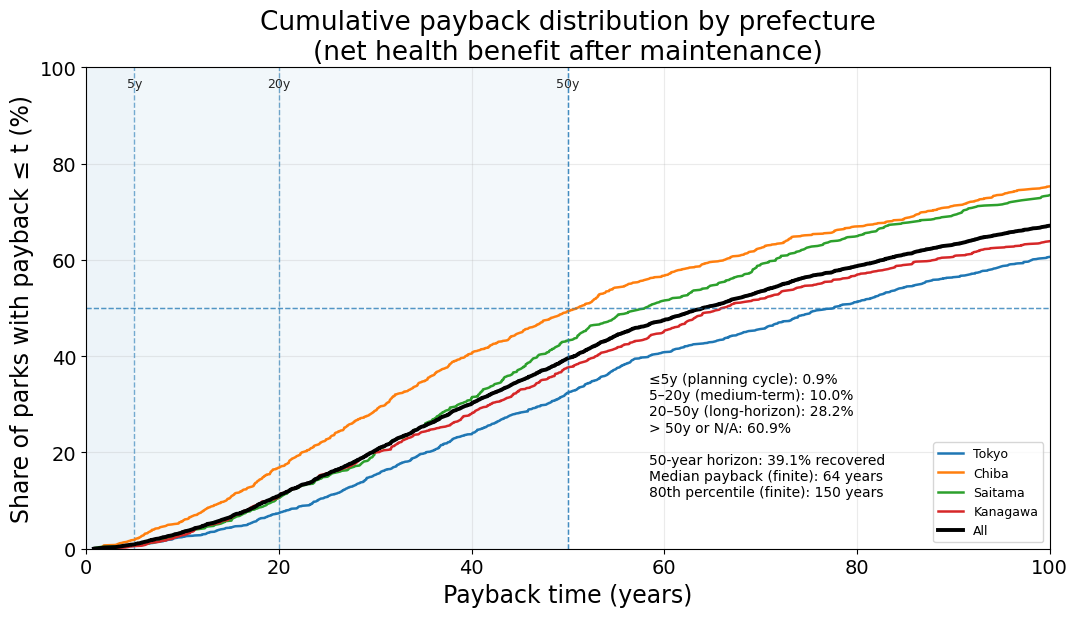

In [25]:
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ====== 你需要确认的 shp 路径 ======
PREF_SHP = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/3_urbanpark_research_area/urbanpark_research_area.shp"

# ====== 方案B阈值 ======
T_SHORT, T_MED, T_LONG = 5, 20, 50
PAYBACK_HORIZON = 50
X_MAX = 100  # 仅影响显示

# ====== 1) 必要列检查 ======
need = ["Lat", "Lng", "payback_years"]
miss = [c for c in need if c not in df.columns]
if miss:
    raise KeyError(f"df 缺少列：{miss}。请确认你当前 df 是 park_agg+cost 计算出来的那张表（4820行）。")

# ====== 2) df -> 点 GeoDataFrame ======
d0 = df.copy()
d0["Lat"] = pd.to_numeric(d0["Lat"], errors="coerce")
d0["Lng"] = pd.to_numeric(d0["Lng"], errors="coerce")
d0 = d0.dropna(subset=["Lat", "Lng"]).copy()

gdf_pts = gpd.GeoDataFrame(
    d0,
    geometry=gpd.points_from_xy(d0["Lng"], d0["Lat"]),
    crs="EPSG:4326"
)

# ====== 3) 读取边界 shp 并自动选“都道府县名称列” ======
gdf_pref = gpd.read_file(PREF_SHP)
if gdf_pref.crs is None:
    gdf_pref = gdf_pref.set_crs("EPSG:4326")
gdf_pref = gdf_pref.to_crs(gdf_pts.crs)

print("Pref SHP rows:", len(gdf_pref))
print("Pref SHP columns:", list(gdf_pref.columns))

# 自动挑字段：哪列最像包含 东京/千叶/埼玉/神奈川
kw_pat = re.compile(r"(東京|千葉|埼玉|神奈川|Tokyo|Chiba|Saitama|Kanagawa|11|12|13|14)", re.IGNORECASE)

best_col, best_hits = None, -1
for c in gdf_pref.columns:
    if c == "geometry":
        continue
    if pd.api.types.is_object_dtype(gdf_pref[c]) or pd.api.types.is_string_dtype(gdf_pref[c]):
        s = gdf_pref[c].astype(str)
        hits = s.str.contains(kw_pat, na=False).sum()
        if hits > best_hits:
            best_hits = hits
            best_col = c

if best_col is None or best_hits <= 0:
    raise ValueError("这个 shp 看起来不包含都道府县信息（东京/千叶/埼玉/神奈川都未命中）。请换一个带属性的四都县边界 shp。")

PREF_NAME_COL = best_col
print("Auto-selected PREF_NAME_COL =", PREF_NAME_COL, "| hits =", best_hits)

# ====== 4) 空间落区（intersects 更稳） ======
joined = gpd.sjoin(
    gdf_pts,
    gdf_pref[[PREF_NAME_COL, "geometry"]].rename(columns={PREF_NAME_COL: "prefecture_raw"}),
    how="left",
    predicate="intersects"
)
print("Spatial join hit rate:", f"{joined['prefecture_raw'].notna().mean():.2%}")
print("Top prefecture_raw:", joined["prefecture_raw"].value_counts(dropna=False).head(10).to_dict())

# ====== 5) 标准化为 Tokyo/Chiba/Saitama/Kanagawa ======
code_map = {11: "Saitama", 12: "Chiba", 13: "Tokyo", 14: "Kanagawa"}

def normalize_pref(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if not s or s.lower() == "nan":
        return np.nan

    m = re.search(r"(?<!\d)(11|12|13|14)(?!\d)", s)
    if m:
        return code_map[int(m.group(1))]

    u = s.upper()
    if "TOKYO" in u or "東京" in s: return "Tokyo"
    if "CHIBA" in u or "千葉" in s: return "Chiba"
    if "SAITAMA" in u or "埼玉" in s: return "Saitama"
    if "KANAGAWA" in u or "神奈川" in s: return "Kanagawa"
    return np.nan

joined["prefecture_std"] = joined["prefecture_raw"].map(normalize_pref)

# 写回原 df（按 index 对齐）
df.loc[joined.index, "prefecture_std"] = joined["prefecture_std"].values

print("prefecture_std counts in df:\n", df["prefecture_std"].value_counts(dropna=False))

# ====== 6) 画 ECDF 累积回本曲线（方案B） ======
plot_df = df[df["prefecture_std"].isin(["Tokyo", "Chiba", "Saitama", "Kanagawa"])].copy()

def ecdf_xy(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").values.astype(float)
    x = x[np.isfinite(x) & (x > 0)]
    if x.size == 0:
        return np.array([]), np.array([])
    x = np.sort(x)
    y = np.arange(1, x.size + 1) / x.size * 100.0
    return x, y

# 如果这里为空，就说明 prefecture_std 没写进去 df（上面 counts 会暴露）
if len(plot_df) == 0:
    raise ValueError("四都县筛选后仍为空：请看上面 prefecture_std counts 是否全是 NaN。")

t = pd.to_numeric(plot_df["payback_years"], errors="coerce")
share_10   = np.mean(t <= T_SHORT) * 100
share_30   = np.mean((t > T_SHORT) & (t <= T_MED)) * 100
share_50   = np.mean((t > T_MED) & (t <= T_LONG)) * 100
share_bey  = np.mean((t > T_LONG) | t.isna()) * 100
share_in50 = np.mean(t <= PAYBACK_HORIZON) * 100
finite = t[np.isfinite(t) & (t > 0)]
med = np.median(finite) if finite.size else np.nan
p80 = np.percentile(finite, 80) if finite.size else np.nan

plt.figure(figsize=(11.0, 6.4))

# ===== 背景区间：按 0–10–30–50 分区 =====
plt.axvspan(0,       T_SHORT, alpha=0.08, zorder=0)   # 0–10
plt.axvspan(T_SHORT, T_MED,   alpha=0.06, zorder=0)   # 10–30
plt.axvspan(T_MED,   T_LONG,  alpha=0.05, zorder=0)   # 30–50

# （可选）>50 的背景也要分区的话，加这一行：
# plt.axvspan(T_LONG, X_MAX, alpha=0.03, zorder=0)

# ===== 参考线：把 10 / 30 / 50 都画出来 =====
plt.axhline(50, ls="--", lw=1, alpha=0.5)

plt.axvline(T_SHORT, ls="--", lw=1, alpha=0.6)  # 10
plt.axvline(T_MED,   ls="--", lw=1, alpha=0.6)  # 30
plt.axvline(T_LONG,  ls="--", lw=1, alpha=0.6)  # 50

# （可选）给三条线加标签，方便读图
y_lab = 98
plt.text(T_SHORT, y_lab, "5y", ha="center", va="top", fontsize=9, alpha=0.85)
plt.text(T_MED,   y_lab, "20y", ha="center", va="top", fontsize=9, alpha=0.85)
plt.text(T_LONG,  y_lab, "50y", ha="center", va="top", fontsize=9, alpha=0.85)


for pref in ["Tokyo", "Chiba", "Saitama", "Kanagawa"]:
    sub = plot_df[plot_df["prefecture_std"] == pref]
    xs, ys = ecdf_xy(sub["payback_years"])
    if xs.size:
        plt.plot(xs, ys, lw=1.8, label=pref)

# All（粗黑线）
xs, ys = ecdf_xy(plot_df["payback_years"])
if xs.size:
    plt.plot(xs, ys, lw=2.8, color="black", label="All")

plt.axhline(50, ls="--", lw=1, alpha=0.5)
plt.axvline(T_LONG, ls="--", lw=1, alpha=0.6)

stat_txt = (
    f"≤{T_SHORT}y (planning cycle): {share_10:.1f}%\n"
    f"{T_SHORT}–{T_MED}y (medium-term): {share_30:.1f}%\n"
    f"{T_MED}–{T_LONG}y (long-horizon): {share_50:.1f}%\n"
    f"> {T_LONG}y or N/A: {share_bey:.1f}%\n\n"
    f"{PAYBACK_HORIZON}-year horizon: {share_in50:.1f}% recovered\n"
    f"Median payback (finite): {med:.0f} years\n"
    f"80th percentile (finite): {p80:.0f} years"
)
plt.gcf().text(0.6, 0.4, stat_txt, fontsize=10, va="top")

plt.title("Cumulative payback distribution by prefecture\n(net health benefit after maintenance)")
plt.xlabel("Payback time (years)")
plt.ylabel("Share of parks with payback ≤ t (%)")
plt.xlim(0, X_MAX)
plt.ylim(0, 100)
plt.grid(True, alpha=0.25)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


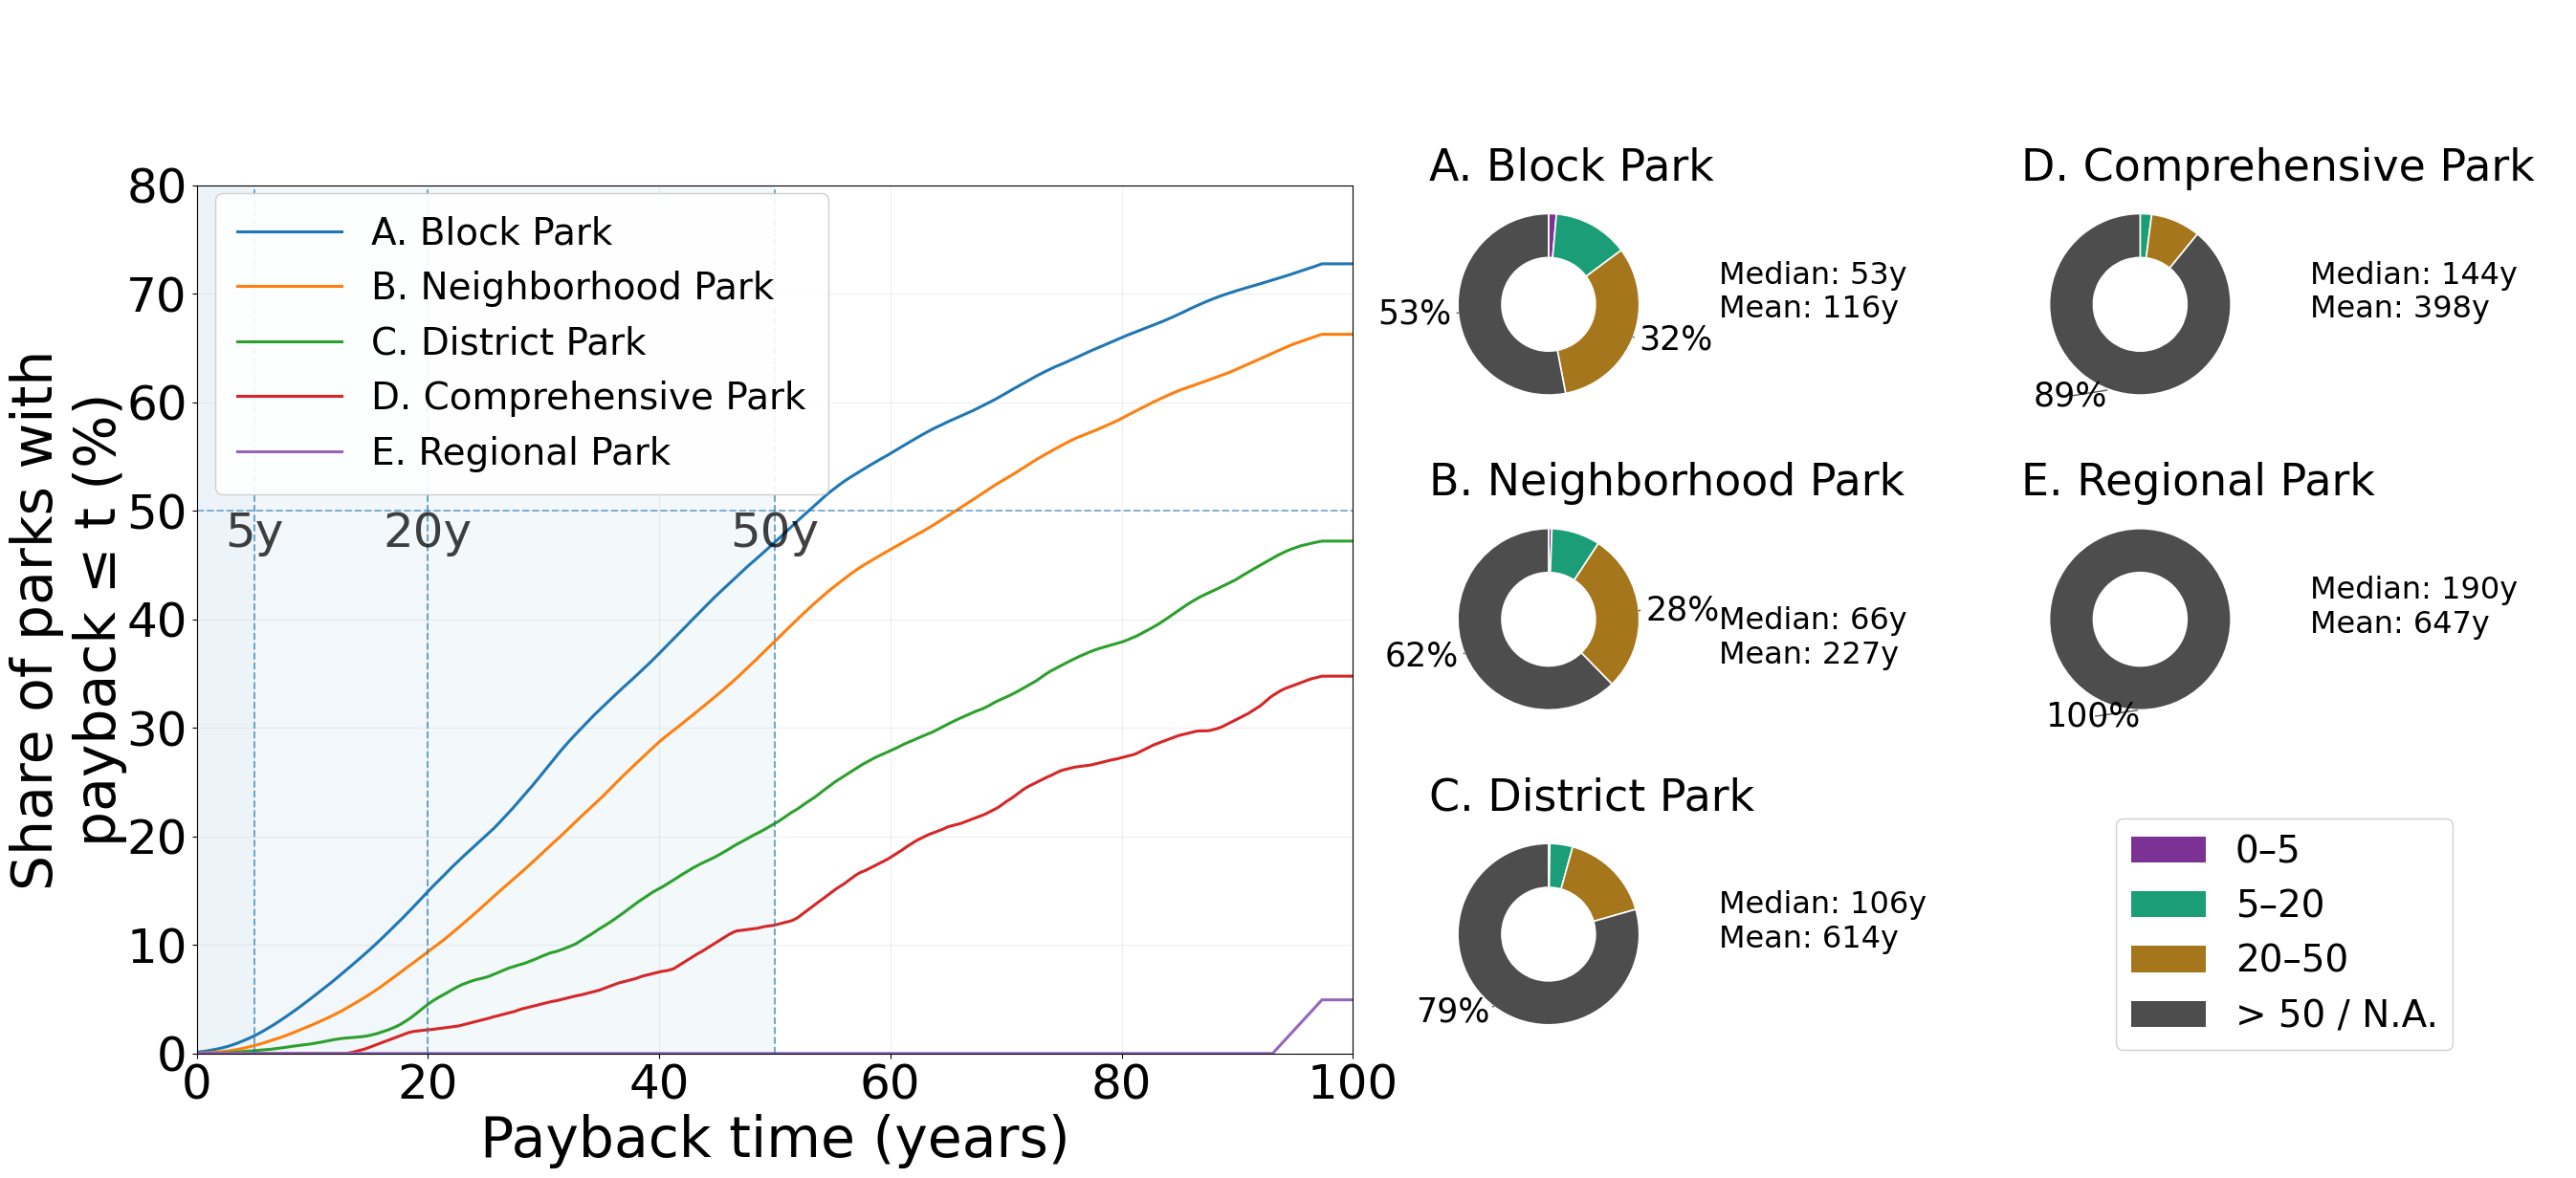

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================
# 0) 数据源与列名
# =========================
SOURCE_DF = df
PAY_COL = "payback_years"
TYPE_NAME_COL = "park_class_name"

# =========================
# 1) 参数
# =========================
T1, T2, T3 = 5, 20, 50
X_MAX = 100
Y_MAX = 80
ECDF_GRID_N = 1500
SMOOTH_WIN = 81

# ✅ 你要“在现在基础上×2.5”：原来 1.2 -> 3.0
TEXT_SCALE = 3.00

# ✅ 你额外要求：图例/饼图标注“稍微小一点”
LEGEND_SHRINK = 0.78       # 公园类型图例缩小
PIE_PCT_SHRINK = 0.70      # 饼图百分比缩小
PIE_TITLE_SHRINK = 0.85    # 饼图标题缩小
PIE_STAT_SHRINK = 0.65     # Median/Mean 缩小

# =========================
# 2) 字号（稳定）
# =========================
plt.rcdefaults()

FONT_MAIN   = int(round(12 * TEXT_SCALE))
FONT_LABEL  = int(round(14 * TEXT_SCALE))
FONT_TICK   = int(round(12 * TEXT_SCALE))

FONT_LEGEND = max(8, int(round(12 * TEXT_SCALE * LEGEND_SHRINK)))
FONT_PIE_TITLE = max(8, int(round(13 * TEXT_SCALE * PIE_TITLE_SHRINK)))
FONT_PIE_STAT  = max(8, int(round(12 * TEXT_SCALE * PIE_STAT_SHRINK)))
FONT_PCT_LABEL = max(8, int(round(12 * TEXT_SCALE * PIE_PCT_SHRINK)))

plt.rcParams.update({
    "font.size": FONT_MAIN,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
})

# =========================
# 3) park_class_name -> A–E 映射
# =========================
NAME2ABC = {}

KEYWORD_RULES = [
    ("block", "A"),
    ("neighborhood", "B"),
    ("neighbourhood", "B"),
    ("district", "C"),
    ("comprehensive", "D"),
    ("regional", "E"),
]

def map_name_to_abc(name: str):
    if name is None:
        return None
    s = str(name).strip()
    if s == "" or s.lower() == "nan":
        return None
    sl = s.lower()
    for k, v in NAME2ABC.items():
        if sl == str(k).strip().lower():
            return v
    for kw, code in KEYWORD_RULES:
        if kw in sl:
            return code
    return None

type_names = {
    "A": "A. Block Park",
    "B": "B. Neighborhood Park",
    "C": "C. District Park",
    "D": "D. Comprehensive Park",
    "E": "E. Regional Park",
}

# =========================
# 4) 构建 d
# =========================
d = SOURCE_DF.copy()
d["abcde"] = d[TYPE_NAME_COL].apply(map_name_to_abc)
d["payback_years_num"] = pd.to_numeric(d[PAY_COL], errors="coerce")
d = d[d["abcde"].isin(list("ABCDE"))].copy()
if len(d) == 0:
    raise ValueError("过滤 A–E 后为空：请检查 park_class_name 映射。")

# =========================
# 5) ECDF + 单调平滑
# =========================
def ecdf_on_grid(x, x_grid):
    x = pd.to_numeric(pd.Series(x), errors="coerce").values.astype(float)
    x = x[np.isfinite(x) & (x > 0)]
    if x.size == 0:
        return np.full_like(x_grid, np.nan, dtype=float)
    x = np.sort(x)
    return np.searchsorted(x, x_grid, side="right") / x.size * 100.0

def smooth_monotone(y, win=81):
    y = np.asarray(y, float)
    m = np.isfinite(y)
    if m.sum() < 5:
        return y
    yy = y.copy()
    yy[~m] = np.interp(np.flatnonzero(~m), np.flatnonzero(m), yy[m])

    win = int(win)
    if win < 3:
        return np.maximum.accumulate(np.clip(yy, 0, 100))
    if win % 2 == 0:
        win += 1

    kernel = np.ones(win, dtype=float) / win
    ys = np.convolve(yy, kernel, mode="same")
    ys = np.clip(ys, 0, 100)
    ys = np.maximum.accumulate(ys)
    return ys

# =========================
# 6) 饼图占比 & 配色
# =========================
def pie_shares(series, t1=5, t2=20, t3=50):
    s = pd.to_numeric(series, errors="coerce")
    if len(s) == 0:
        return [0, 0, 0, 100]
    a = np.mean(s.notna() & (s > 0) & (s <= t1)) * 100
    b = np.mean(s.notna() & (s > t1) & (s <= t2)) * 100
    c = np.mean(s.notna() & (s > t2) & (s <= t3)) * 100
    d_ = 100 - (a + b + c)
    return [a, b, c, d_]

pie_labels = [f"0–{T1}", f"{T1}–{T2}", f"{T2}–{T3}", f"> {T3} / N.A."]
pie_color_list = ["#7b3294", "#1b9e77", "#a6761d", "#4d4d4d"]

def add_outside_labels(ax, wedges, vals, min_pct=22, r_text=1.08):
    """只标大扇区，且不越界"""
    total = np.sum(vals) if np.sum(vals) > 0 else 1.0
    for w, v in zip(wedges, vals):
        pct = v / total * 100
        if pct < min_pct:
            continue
        ang = (w.theta1 + w.theta2) / 2.0
        ang_rad = np.deg2rad(ang)
        x = np.cos(ang_rad) * w.r
        y = np.sin(ang_rad) * w.r
        xt = np.cos(ang_rad) * r_text
        yt = np.sin(ang_rad) * r_text
        ha = "left" if xt >= 0 else "right"
        ax.annotate(
            f"{pct:.0f}%",
            xy=(x, y),
            xytext=(xt, yt),
            ha=ha, va="center",
            fontsize=FONT_PCT_LABEL,
            arrowprops=dict(arrowstyle="-", lw=1.0, color="0.35"),
            clip_on=False
        )

# =========================
# 7) 布局：GridSpec（保证不重叠）
#    顶部一行专门放“公园类型图例（5行）”
#    下方：左主图；右侧：饼图(3x2) + 每个饼图旁边一个统计文字轴
# =========================
fig = plt.figure(figsize=(28, 12), constrained_layout=False)


gs0 = fig.add_gridspec(
    nrows=2, ncols=1,
    height_ratios=[0.16, 0.84],   # ✅ 顶部留给5行图例
    left=0.1, right=0.985, top=0.97, bottom=0.06,
    hspace=0.02
)

# 顶部：公园类型图例专用轴
ax_top = fig.add_subplot(gs0[0, 0])

ax_top.axis("off")
# ✅ 保证在最上层
ax_top.set_zorder(50)
ax_top.patch.set_alpha(0)

leg = ax_top.legend(
    handles=line_handles,
    labels=line_labels,
    loc="upper left",
    bbox_to_anchor=(0.00, 0.0),  # ✅ y 越小越往下（但仍在顶部图例带内）
    ncol=1,
    frameon=True,
    framealpha=0.92,
    borderpad=0.6,
    handlelength=2.8
)
leg.set_zorder(100)

# 下方：主体区 1x2
gs_main = gs0[1, 0].subgridspec(
    nrows=1, ncols=2,
    width_ratios=[1, 1],
    wspace=0.05
)

# 左：ECDF 主图
ax = fig.add_subplot(gs_main[0, 0])

# 右：饼图区（3行 x 4列：pie + stat | pie + stat）
gs_pie = gs_main[0, 1].subgridspec(
    nrows=3, ncols=4,
    width_ratios=[1.0, 0.95, 1.0, 0.95],
    wspace=0.1, hspace=0.32
)

# 右下角：分类图例专用轴
ax_catleg = fig.add_subplot(gs_pie[2, 2:4])
ax_catleg.axis("off")

# =========================
# 8) 左侧主图绘制
# =========================
x_grid = np.linspace(0, X_MAX, ECDF_GRID_N)

ax.axvspan(0,  T1, alpha=0.08)
ax.axvspan(T1, T2, alpha=0.06)
ax.axvspan(T2, T3, alpha=0.05)

line_handles, line_labels = [], []
for g in "ABCDE":
    sub = d[d["abcde"] == g]
    y = ecdf_on_grid(sub["payback_years_num"], x_grid)
    y = smooth_monotone(y, win=SMOOTH_WIN)
    if np.isfinite(y).any():
        h, = ax.plot(x_grid, y, lw=2.2)
        line_handles.append(h)
        line_labels.append(type_names[g])

# 参考线
ax.axhline(50, ls="--", lw=1.4, alpha=0.55)
for t, lab in [(T1, "5y"), (T2, "20y"), (T3, "50y")]:
    ax.axvline(t, ls="--", lw=1.4, alpha=0.65)
    ax.text(t, Y_MAX - 30.0, lab, ha="center", va="top", alpha=0.75)

ax.set_xlabel("Payback time (years)")

# ✅ y轴名字避免贴外框：两行 + labelpad + 坐标微调
ax.set_ylabel("Share of parks with\npayback ≤ t (%)", labelpad=18)
ax.yaxis.set_label_coords(-0.06, 0.5)

ax.set_xlim(0, X_MAX)
ax.set_ylim(0, Y_MAX)
ax.grid(True, alpha=0.20)

# =========================
# 9) 顶部：公园类型图例（五行/单列）
# =========================
ax_top.legend(
    handles=line_handles,
    labels=line_labels,
    loc="upper left",
    bbox_to_anchor=(0.00, 0),  # ✅ y 越小越往下
    ncol=1,
    frameon=True,
    framealpha=0.92,
    borderpad=0.6,
    handlelength=2.8
)

# =========================
# 10) 右侧：饼图 + 统计文字（彻底分离，不重叠）
# =========================
# 放置位置：A/D 在第0行，B/E 在第1行，C 在第2行左侧
pie_layout = {
    "A": (0, 0),
    "D": (0, 2),
    "B": (1, 0),
    "E": (1, 2),
    "C": (2, 0),
}

for g, (r, c0) in pie_layout.items():
    # 饼图轴
    pax = fig.add_subplot(gs_pie[r, c0])
    pax.set_aspect("equal")
    pax.axis("off")
    pax.set_zorder(3)                 # ✅ 饼图轴在上层
    # 统计文字轴
    tax = fig.add_subplot(gs_pie[r, c0 + 1])
    tax.axis("off")
    tax.set_zorder(2)                 # ✅ 统计轴在下层
    tax.set_facecolor("none")         # ✅ 背景透明
    tax.patch.set_alpha(0)            # ✅ 防止盖住 28%



    sub = d[d["abcde"] == g]
    vals = pie_shares(sub["payback_years_num"], T1, T2, T3)

    s = pd.to_numeric(sub["payback_years_num"], errors="coerce")
    s = s[np.isfinite(s) & (s > 0)]
    med = np.median(s) if len(s) else np.nan
    mean = np.mean(s) if len(s) else np.nan

    wedges, _ = pax.pie(
        vals,
        startangle=90,
        counterclock=False,
        radius=0.95,
        wedgeprops=dict(width=0.46, edgecolor="white", linewidth=1.2),
    )
    for w, col in zip(wedges, pie_color_list):
        w.set_facecolor(col)

    add_outside_labels(pax, wedges, vals, min_pct=22, r_text=1.02)

    # ✅ 标题放在饼图轴上方（不会挤到别的轴）
    pax.text(0.0, 0.98, type_names[g],
             transform=pax.transAxes, ha="left", va="bottom",
             fontsize=FONT_PIE_TITLE)

    # ✅ Median/Mean 放到“统计文字轴”里（绝对不会压到饼图）
    stat = f"Median: {med:.0f}y\nMean: {mean:.0f}y" if np.isfinite(med) else "Median: N/A\nMean: N/A"
    y_stat = 0.42 if g == "B" else 0.55
    tax.text(0.02, y_stat, stat,

             ha="left", va="center",
             fontsize=FONT_PIE_STAT,
             bbox=dict(facecolor="white", alpha=0.90, edgecolor="none",
                       boxstyle="round,pad=0.25"))

# =========================
# 11) 右下角：分类图例（独立轴，不与任何元素重叠）
# =========================
pie_handles = [Patch(facecolor=pie_color_list[i], edgecolor="none", label=pie_labels[i]) for i in range(4)]
ax_catleg.legend(
    handles=pie_handles,
    loc="center",
    ncol=1,
    frameon=True,
    framealpha=0.92
)

plt.show()


[detect] data_0_with_park_class.csv: osm_col=osm_id | abcde_col=park_class | hit≈100.00%
[detect] data_1_with_park_class.csv: osm_col=osm_id | abcde_col=park_class | hit≈100.00%
5%-95% range: [-10032.66, 16374.13] | kept 4,337/4,819 (90.0%), excluded 482
bin width = 1000.0 | bin count = 28
Saved -> /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/net_annual_per_m2_hist_bin1000_stacked_abcde_5_95.png | exists = True


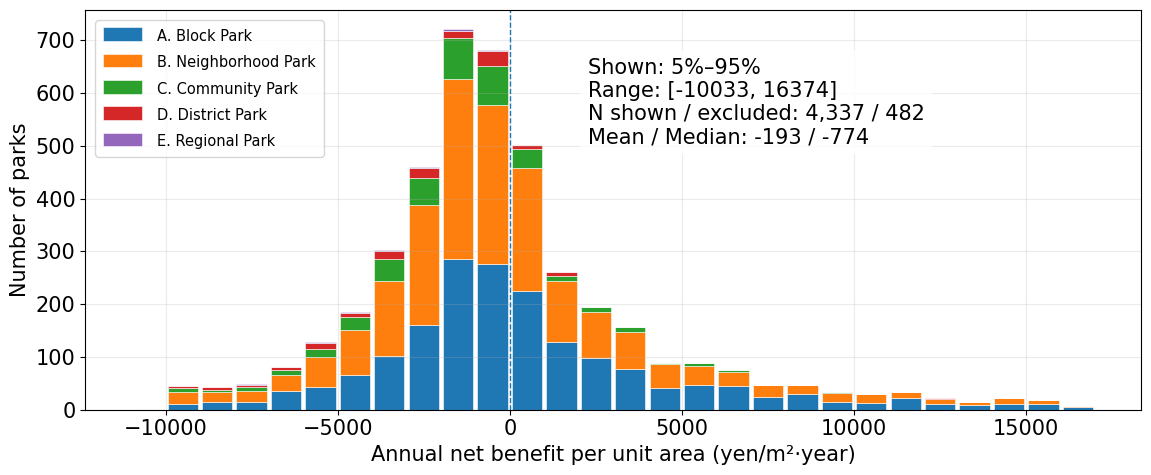

In [114]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =======================
# CONFIG
# =======================
BIN_W = 1000.0   # 每1000一个柱子
CAP_YEARS = 50

CSV0 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/5_study_area_stay/out_2019_parts_no_filter/_agg_out_delta_time/_cleaned_v4_area_patched_kokyo/clean_part/data_0_with_park_class.csv"
CSV1 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/5_study_area_stay/out_2019_parts_no_filter/_agg_out_delta_time/_cleaned_v4_area_patched_kokyo/clean_part/data_1_with_park_class.csv"

SAVE_DIR = globals().get("OUT_DIR", os.getcwd())
os.makedirs(SAVE_DIR, exist_ok=True)

# ✅ 图例名称
TYPE_NAME = {
    "A": "A. Block Park",
    "B": "B. Neighborhood Park",
    "C": "C. Community Park",
    "D": "D. District Park",
    "E": "E. Regional Park",
}

# =======================
# ✅ 字号整体 ×2（含图例/注释/坐标轴）
# =======================
TEXT_SCALE = 1.5

plt.rcdefaults()
BASE_FONT = int(round(10 * TEXT_SCALE))
LABEL_FONT = int(round(10 * TEXT_SCALE))
TICK_FONT  = int(round(10 * TEXT_SCALE))
LEGEND_FONT = int(round(9 * TEXT_SCALE))
NOTE_FONT = int(round(10 * TEXT_SCALE))

plt.rcParams.update({
    "font.size": BASE_FONT,
    "axes.labelsize": LABEL_FONT,
    "xtick.labelsize": TICK_FONT,
    "ytick.labelsize": TICK_FONT,
    "legend.fontsize": LEGEND_FONT,
})

# =======================
# 0) 基础数据准备：确保有 net_annual_yen_per_m2
# =======================
need = ["osm_id", "area_m2", "annual_benefit_yen", "annual_maint_yen"]
miss = [c for c in need if c not in df.columns]
if miss:
    raise KeyError(f"df 缺少列：{miss}。请先跑回本年限那一套计算（含 annual_benefit_yen/annual_maint_yen）。")

d = df.copy()

d["osm_id_norm"] = d["osm_id"].astype(str).str.strip().str.replace(r"\.0$", "", regex=True)

d["area_m2"] = pd.to_numeric(d["area_m2"], errors="coerce")
d["annual_benefit_yen"] = pd.to_numeric(d["annual_benefit_yen"], errors="coerce")
d["annual_maint_yen"] = pd.to_numeric(d["annual_maint_yen"], errors="coerce")

d = d[np.isfinite(d["area_m2"]) & (d["area_m2"] > 0)].copy()

if "price_fina" not in d.columns:
    raise KeyError("df 里没有 price_fina。请用你回本年限的 df（里面应包含 price_fina）。")

d["price_fina"] = pd.to_numeric(d["price_fina"], errors="coerce")
d = d[np.isfinite(d["price_fina"]) & (d["price_fina"] > 0)].copy()

d["annual_land_cost_yen"] = (d["price_fina"] * d["area_m2"]) / CAP_YEARS

d["net_annual_yen_per_m2"] = (
    d["annual_benefit_yen"] - d["annual_maint_yen"] - d["annual_land_cost_yen"]
) / d["area_m2"]

# =======================
# 1) 如果还没有 abcde，就从两个原始CSV抽取并 merge
# =======================
def norm_osm(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    return s.str.replace(r"\.0$", "", regex=True)

def extract_abcde(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().upper()
    if not s or s == "NAN":
        return np.nan
    m = re.search(r"\b([A-E])\b", s)
    if m:
        return m.group(1)
    m = re.search(r"([A-E])", s)
    return m.group(1) if m else np.nan

def detect_abcde_column(csv_path: str, osm_idx=3, sample_n=5000) -> tuple[str, str]:
    head = pd.read_csv(csv_path, nrows=0)
    cols = list(head.columns)
    if len(cols) <= osm_idx:
        raise ValueError(f"{csv_path} 列数不足，无法按第4列取 osm_id。cols={len(cols)}")
    osm_col = cols[osm_idx]

    kw = ["abcde", "grade", "class", "type", "category", "park_class", "park_type"]
    name_cands = [c for c in cols if any(k in c.lower() for k in kw) and c != osm_col]

    usecols = [osm_col] + (name_cands if name_cands else cols)
    usecols = list(dict.fromkeys(usecols))[:min(len(usecols), 60)]

    sample = pd.read_csv(csv_path, usecols=usecols, nrows=sample_n)
    best_col, best_score = None, -1
    for c in sample.columns:
        if c == osm_col:
            continue
        s = sample[c].map(extract_abcde)
        score = s.isin(list("ABCDE")).mean()
        if score > best_score:
            best_score, best_col = score, c

    if best_col is None or best_score < 0.05:
        raise ValueError(f"无法在 {csv_path} 自动识别 ABCDE 列（最高命中率={best_score:.3f}）。")
    print(f"[detect] {os.path.basename(csv_path)}: osm_col={osm_col} | abcde_col={best_col} | hit≈{best_score:.2%}")
    return osm_col, best_col

def build_osm_to_abcde(csv_paths, osm_idx=3, chunksize=400_000) -> pd.DataFrame:
    mp = {}
    for p in csv_paths:
        osm_col, abc_col = detect_abcde_column(p, osm_idx=osm_idx)
        for chunk in pd.read_csv(p, usecols=[osm_col, abc_col], chunksize=chunksize):
            chunk = chunk.rename(columns={osm_col: "osm_id_raw", abc_col: "abcde_raw"})
            chunk["osm_id_norm"] = norm_osm(chunk["osm_id_raw"])
            chunk["abcde"] = chunk["abcde_raw"].map(extract_abcde)
            chunk = chunk.dropna(subset=["osm_id_norm", "abcde"])
            for k, v in zip(chunk["osm_id_norm"].values, chunk["abcde"].values):
                mp[k] = v
    out = pd.DataFrame({"osm_id_norm": list(mp.keys()), "abcde": list(mp.values())})
    return out

if "abcde" not in d.columns:
    abcde_map = build_osm_to_abcde([CSV0, CSV1], osm_idx=3)
    d = d.merge(abcde_map, on="osm_id_norm", how="left")

d = d[d["abcde"].isin(list("ABCDE"))].copy()
if len(d) == 0:
    raise ValueError("没有任何 A–E 类别的记录。请检查 ABCDE 合并是否成功。")

# =======================
# 2) 5%–95% 区间筛选 + 计算均值/中位数
# =======================
x_all = pd.to_numeric(d["net_annual_yen_per_m2"], errors="coerce")
mask_all = np.isfinite(x_all)
x_all = x_all[mask_all]
d = d.loc[mask_all].copy()

if x_all.size == 0:
    raise ValueError("net_annual_yen_per_m2 没有有效值。")

q05, q95 = np.percentile(x_all.values.astype(float), [5, 95])
inrange = (d["net_annual_yen_per_m2"] >= q05) & (d["net_annual_yen_per_m2"] <= q95)
d_in = d[inrange].copy()

excluded = len(d) - len(d_in)
print(f"5%-95% range: [{q05:.2f}, {q95:.2f}] | kept {len(d_in):,}/{len(d):,} ({len(d_in)/len(d)*100:.1f}%), excluded {excluded:,}")

x = d_in["net_annual_yen_per_m2"].values.astype(float)
mean_x = float(np.mean(x))
median_x = float(np.median(x))

# =======================
# 3) 固定 bin 宽度=1000，并堆叠 ABCDE
# =======================
left = np.floor(x.min() / BIN_W) * BIN_W
right = np.ceil(x.max() / BIN_W) * BIN_W
bins = np.arange(left, right + BIN_W, BIN_W)
print("bin width =", BIN_W, "| bin count =", len(bins) - 1)

groups = ["A", "B", "C", "D", "E"]
data_by_g = [d_in.loc[d_in["abcde"] == g, "net_annual_yen_per_m2"].values.astype(float) for g in groups]
legend_labels = [TYPE_NAME.get(g, f"Type {g}") for g in groups]

# =======================
# 4) 作图（✅ 无总标题；✅ 画面更“扁”）
# =======================
# ✅ “压扁一点”：高度变矮一些（原 6.4 -> 5.0）
fig, ax = plt.subplots(figsize=(12.0, 5.0))

ax.hist(
    data_by_g,
    bins=bins,
    stacked=True,
    rwidth=0.88,
    edgecolor="white",
    linewidth=0.4,
    label=legend_labels,
)

ax.axvline(0, linestyle="--", linewidth=1.0)
ax.grid(True, alpha=0.25)

ax.set_xlabel("Annual net benefit per unit area (yen/m²·year)")
ax.set_ylabel("Number of parks")

# ✅ 注释：信息不丢，但更紧凑，避免字号×2 后挤占空间/重叠
note = (
    "Shown: 5%–95%\n"
    f"Range: [{q05:.0f}, {q95:.0f}]\n"
    f"N shown / excluded: {len(d_in):,} / {excluded:,}\n"
    f"Mean / Median: {mean_x:.0f} / {median_x:.0f}"
)
fig.text(
    0.5, 0.86, note,   # 位置仍在右上角附近；稍微左移一点给大字号留空间
    fontsize=NOTE_FONT, va="top",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", boxstyle="round,pad=0.35")
)

# ✅ 图例（位置不变：左上角；字号已由 rcParams ×2）
leg = ax.legend(loc="upper left", frameon=True, framealpha=0.8)
for t in leg.get_texts():
    t.set_fontsize(t.get_fontsize() * 0.75)  # 0.85/0.8 这种是“稍微小一点”


# ✅ 避免元素重叠：稍微多留一点上边距给注释框
plt.tight_layout(rect=[0.00, 0.00, 0.98, 1.00])

out_png = os.path.join(SAVE_DIR, "net_annual_per_m2_hist_bin1000_stacked_abcde_5_95.png")
fig.savefig(out_png, dpi=220, bbox_inches="tight")
print("Saved ->", out_png, "| exists =", os.path.exists(out_png))

plt.show()
plt.close(fig)


[detect] data_0_with_park_class.csv: osm_col=osm_id | abcde_col=park_class | hit≈100.00%
[detect] data_1_with_park_class.csv: osm_col=osm_id | abcde_col=park_class | hit≈100.00%
5%-95% range: [-10032.66, 16374.13] | kept 4,337/4,819 (90.0%), excluded 482
bin width = 1000.0 | bin count = 28
Saved -> /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/net_annual_per_m2_hist_bin1000_stacked_abcde_5_95.png | exists = True


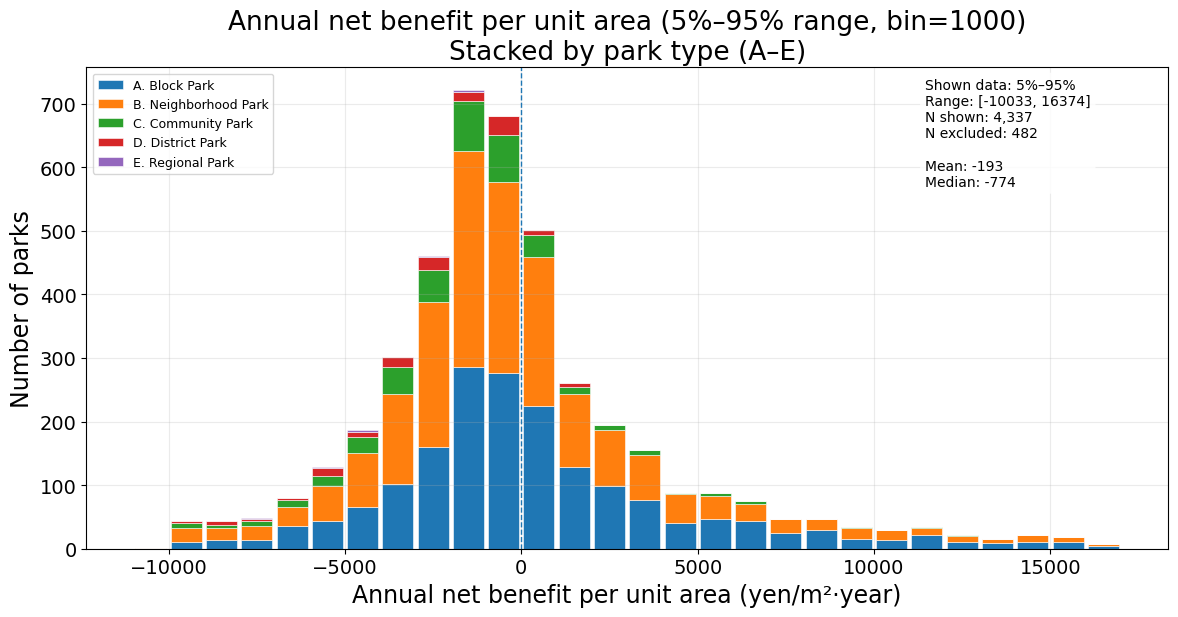

In [13]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =======================
# CONFIG
# =======================
BIN_W = 1000.0   # 每1000一个柱子
CAP_YEARS = 50

# 你那两个原始文件（含 ABCDE 类别）
CSV0 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/5_study_area_stay/out_2019_parts_no_filter/_agg_out_delta_time/_cleaned_v4_area_patched_kokyo/clean_part/data_0_with_park_class.csv"
CSV1 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/5_study_area_stay/out_2019_parts_no_filter/_agg_out_delta_time/_cleaned_v4_area_patched_kokyo/clean_part/data_1_with_park_class.csv"

# 输出目录：优先 OUT_DIR
SAVE_DIR = globals().get("OUT_DIR", os.getcwd())
os.makedirs(SAVE_DIR, exist_ok=True)

# =======================
# ✅ 图例名称：把 Type A–E 换成 A. xxx
#    你按实际论文口径改这里即可
# =======================
TYPE_NAME = {
    "A": "A. Block Park",
    "B": "B. Neighborhood Park",
    "C": "C. Community Park",
    "D": "D. District Park",
    "E": "E. Regional Park",
}

# =======================
# 0) 基础数据准备：确保有 net_annual_yen_per_m2
#    净收益 = annual_benefit - annual_maint - (price_fina*area)/50，然后再除以 area
# =======================
need = ["osm_id", "area_m2", "annual_benefit_yen", "annual_maint_yen"]
miss = [c for c in need if c not in df.columns]
if miss:
    raise KeyError(f"df 缺少列：{miss}。请先跑回本年限那一套计算（含 annual_benefit_yen/annual_maint_yen）。")

d = df.copy()

# 规范化 osm_id
d["osm_id_norm"] = d["osm_id"].astype(str).str.strip().str.replace(r"\.0$", "", regex=True)

# 数值化
d["area_m2"] = pd.to_numeric(d["area_m2"], errors="coerce")
d["annual_benefit_yen"] = pd.to_numeric(d["annual_benefit_yen"], errors="coerce")
d["annual_maint_yen"] = pd.to_numeric(d["annual_maint_yen"], errors="coerce")

# 必须 area>0
d = d[np.isfinite(d["area_m2"]) & (d["area_m2"] > 0)].copy()

# price_fina：优先用 df 里已有的；如果没有就报错
if "price_fina" not in d.columns:
    raise KeyError("df 里没有 price_fina。请用你回本年限的 df（里面应包含 price_fina）。")

d["price_fina"] = pd.to_numeric(d["price_fina"], errors="coerce")
d = d[np.isfinite(d["price_fina"]) & (d["price_fina"] > 0)].copy()

# 年化地价成本
d["annual_land_cost_yen"] = (d["price_fina"] * d["area_m2"]) / CAP_YEARS

# 单位面积年净收益（最终 x）
d["net_annual_yen_per_m2"] = (
    d["annual_benefit_yen"] - d["annual_maint_yen"] - d["annual_land_cost_yen"]
) / d["area_m2"]

# =======================
# 1) 如果还没有 abcde，就从两个原始CSV抽取并 merge
# =======================
def norm_osm(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    return s.str.replace(r"\.0$", "", regex=True)

def extract_abcde(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().upper()
    if not s or s == "NAN":
        return np.nan
    m = re.search(r"\b([A-E])\b", s)
    if m:
        return m.group(1)
    m = re.search(r"([A-E])", s)
    return m.group(1) if m else np.nan

def detect_abcde_column(csv_path: str, osm_idx=3, sample_n=5000) -> tuple[str, str]:
    """返回 (osm_col_name, abcde_col_name)；osm_col 按第4列取。"""
    head = pd.read_csv(csv_path, nrows=0)
    cols = list(head.columns)
    if len(cols) <= osm_idx:
        raise ValueError(f"{csv_path} 列数不足，无法按第4列取 osm_id。cols={len(cols)}")
    osm_col = cols[osm_idx]

    kw = ["abcde", "grade", "class", "type", "category", "park_class", "park_type"]
    name_cands = [c for c in cols if any(k in c.lower() for k in kw) and c != osm_col]

    usecols = [osm_col] + (name_cands if name_cands else cols)
    usecols = list(dict.fromkeys(usecols))[:min(len(usecols), 60)]

    sample = pd.read_csv(csv_path, usecols=usecols, nrows=sample_n)
    best_col, best_score = None, -1
    for c in sample.columns:
        if c == osm_col:
            continue
        s = sample[c].map(extract_abcde)
        score = s.isin(list("ABCDE")).mean()
        if score > best_score:
            best_score, best_col = score, c

    if best_col is None or best_score < 0.05:
        raise ValueError(f"无法在 {csv_path} 自动识别 ABCDE 列（最高命中率={best_score:.3f}）。")
    print(f"[detect] {os.path.basename(csv_path)}: osm_col={osm_col} | abcde_col={best_col} | hit≈{best_score:.2%}")
    return osm_col, best_col

def build_osm_to_abcde(csv_paths, osm_idx=3, chunksize=400_000) -> pd.DataFrame:
    mp = {}
    for p in csv_paths:
        osm_col, abc_col = detect_abcde_column(p, osm_idx=osm_idx)
        for chunk in pd.read_csv(p, usecols=[osm_col, abc_col], chunksize=chunksize):
            chunk = chunk.rename(columns={osm_col: "osm_id_raw", abc_col: "abcde_raw"})
            chunk["osm_id_norm"] = norm_osm(chunk["osm_id_raw"])
            chunk["abcde"] = chunk["abcde_raw"].map(extract_abcde)
            chunk = chunk.dropna(subset=["osm_id_norm", "abcde"])
            for k, v in zip(chunk["osm_id_norm"].values, chunk["abcde"].values):
                mp[k] = v
    out = pd.DataFrame({"osm_id_norm": list(mp.keys()), "abcde": list(mp.values())})
    return out

if "abcde" not in d.columns:
    abcde_map = build_osm_to_abcde([CSV0, CSV1], osm_idx=3)
    d = d.merge(abcde_map, on="osm_id_norm", how="left")

# 只保留 A-E（其余不参与堆叠）
d = d[d["abcde"].isin(list("ABCDE"))].copy()
if len(d) == 0:
    raise ValueError("没有任何 A–E 类别的记录。请检查 ABCDE 合并是否成功。")

# =======================
# 2) 5%–95% 区间筛选 + 计算均值/中位数
# =======================
x_all = pd.to_numeric(d["net_annual_yen_per_m2"], errors="coerce")
mask_all = np.isfinite(x_all)
x_all = x_all[mask_all]
d = d.loc[mask_all].copy()

if x_all.size == 0:
    raise ValueError("net_annual_yen_per_m2 没有有效值。")

q05, q95 = np.percentile(x_all.values.astype(float), [5, 95])
inrange = (d["net_annual_yen_per_m2"] >= q05) & (d["net_annual_yen_per_m2"] <= q95)
d_in = d[inrange].copy()

excluded = len(d) - len(d_in)
print(f"5%-95% range: [{q05:.2f}, {q95:.2f}] | kept {len(d_in):,}/{len(d):,} ({len(d_in)/len(d)*100:.1f}%), excluded {excluded:,}")

x = d_in["net_annual_yen_per_m2"].values.astype(float)
mean_x = float(np.mean(x))
median_x = float(np.median(x))

# =======================
# 3) 固定 bin 宽度=1000，并堆叠 ABCDE
# =======================
left = np.floor(x.min() / BIN_W) * BIN_W
right = np.ceil(x.max() / BIN_W) * BIN_W
bins = np.arange(left, right + BIN_W, BIN_W)
print("bin width =", BIN_W, "| bin count =", len(bins) - 1)

groups = ["A", "B", "C", "D", "E"]
data_by_g = [d_in.loc[d_in["abcde"] == g, "net_annual_yen_per_m2"].values.astype(float) for g in groups]

# ✅ 图例标签：带名字
legend_labels = [TYPE_NAME.get(g, f"Type {g}") for g in groups]

# =======================
# 4) 作图
# =======================
fig = plt.figure(figsize=(12.0, 6.4))

plt.hist(
    data_by_g,
    bins=bins,
    stacked=True,
    rwidth=0.88,
    edgecolor="white",
    linewidth=0.4,
    label=legend_labels,     # ✅ 这里替换了
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.grid(True, alpha=0.25)

plt.title("Annual net benefit per unit area (5%–95% range, bin=1000)\nStacked by park type (A–E)")
plt.xlabel("Annual net benefit per unit area (yen/m²·year)")
plt.ylabel("Number of parks")

note = (
    f"Shown data: 5%–95%\n"
    f"Range: [{q05:.0f}, {q95:.0f}]\n"
    f"N shown: {len(d_in):,}\n"
    f"N excluded: {excluded:,}\n\n"
    f"Mean: {mean_x:.0f}\n"
    f"Median: {median_x:.0f}"
)
fig.text(
    0.78, 0.86, note,
    fontsize=10, va="top",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", boxstyle="round,pad=0.35")
)

plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()

out_png = os.path.join(SAVE_DIR, "net_annual_per_m2_hist_bin1000_stacked_abcde_5_95.png")
fig.savefig(out_png, dpi=220, bbox_inches="tight")
print("Saved ->", out_png, "| exists =", os.path.exists(out_png))

plt.show()
plt.close(fig)
